# Практическая работа № 1

Автор: Кашымбеков Актан Ийгиликович

## Цель

Загрузить датасет об использовании социальных сетей, изучить его
структуру и качество данных, исследовать связь времени в соцсетях
с продолжительностью сна.

Источник: https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life

In [1]:
from pathlib import Path

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data_path = Path("../data/raw/Social_media_impact_on_life.csv")
df = pd.read_csv(data_path)

df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


## Структура данных

In [3]:
print("Строк и столбцов:", df.shape)
df.info()

Строк и столбцов: (4500, 16)
<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   str    
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   str    
 3   Academic_Level               4500 non-null   str    
 4   Primary_Platform             4500 non-null   str    
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   str    
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   str    
 12  Perceived_Stress_Score       4454 non-null   float64
 13  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4500.0,18.703333,1.981182,15.0,17.0,19.00,20.00,26.0
Daily_Usage_Hours,4500.0,5.295933,2.604497,0.9,3.4,4.70,6.60,14.0
Weekend_Extra_Hours,4500.0,1.796844,0.699245,0.0,1.3,1.80,2.30,4.5
Sleep_Duration_Hours,4500.0,6.701333,1.189998,3.0,6.0,6.80,7.50,10.5
Sleep_Quality_Score,4500.0,2.472000,1.030484,1.0,2.0,3.00,3.00,5.0
Perceived_Stress_Score,4454.0,13.512124,7.072859,0.0,9.0,13.00,18.00,40.0
Mental_Health_Index,4500.0,79.873111,12.876044,32.0,72.0,82.00,89.00,98.0
Academic_Performance_GPA,4415.0,3.429282,0.392662,1.9,3.2,3.46,3.72,4.0


## Проверка качества данных 

In [5]:
df.isna().sum().sort_values(ascending=False)

Academic_Performance_GPA       85
Perceived_Stress_Score         46
Student_ID                      0
Age                             0
Primary_Platform                0
Daily_Usage_Hours               0
Gender                          0
Academic_Level                  0
Device_Type                     0
Weekend_Extra_Hours             0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Social_Comparison_Frequency     0
Late_Night_Usage                0
Mental_Health_Index             0
Overall_Impact                  0
dtype: int64

In [6]:
print("Полные дубликаты:", df.duplicated().sum())
print("Повторяющиеся ID:", df["Student_ID"].duplicated().sum())

Полные дубликаты: 0
Повторяющиеся ID: 0


## Продолжительность сна

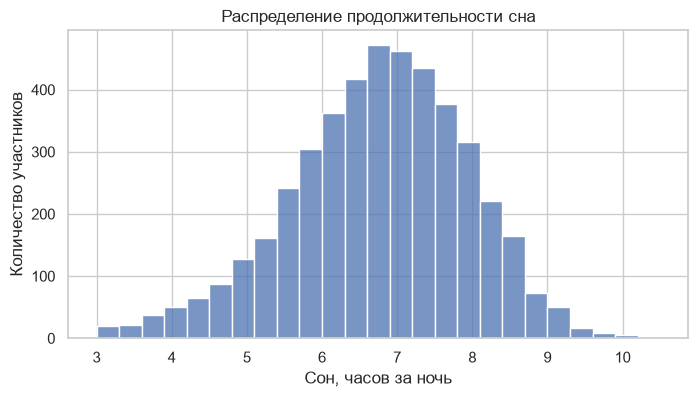

In [7]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Sleep_Duration_Hours", bins=25)

plt.title("Распределение продолжительности сна")
plt.xlabel("Сон, часов за ночь")
plt.ylabel("Количество участников")
plt.show()

# Связь использования соцсетей со сном.

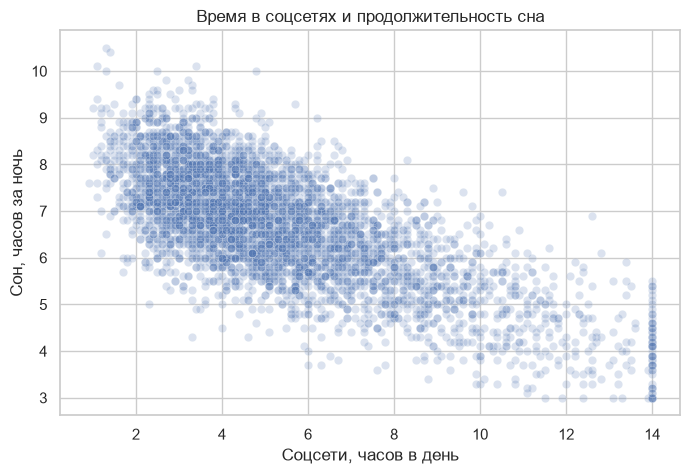

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Daily_Usage_Hours",
    y="Sleep_Duration_Hours",
    alpha=0.2
)

plt.title("Время в соцсетях и продолжительность сна")
plt.xlabel("Соцсети, часов в день")
plt.ylabel("Сон, часов за ночь")
plt.show()

In [9]:
df.groupby("Late_Night_Usage")["Sleep_Duration_Hours"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Late_Night_Usage,,,
False,1856,7.085884,7.1
True,2644,6.431392,6.5


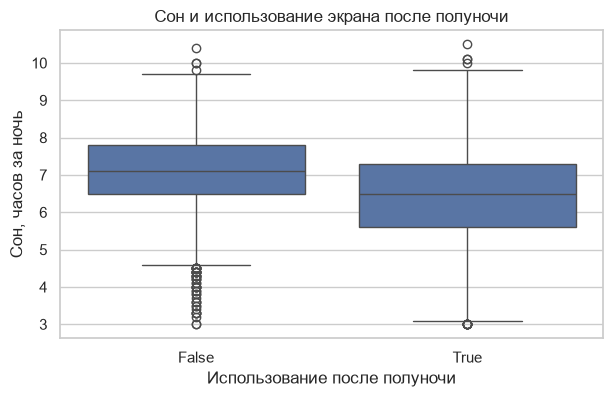

In [10]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Late_Night_Usage",
    y="Sleep_Duration_Hours"
)

plt.title("Сон и использование экрана после полуночи")
plt.xlabel("Использование после полуночи")
plt.ylabel("Сон, часов за ночь")
plt.show()

In [11]:
feature_columns = [
    "Age",
    "Gender",
    "Academic_Level",
    "Primary_Platform",
    "Daily_Usage_Hours",
    "Weekend_Extra_Hours",
    "Device_Type",
    "Late_Night_Usage",
    "Social_Comparison_Frequency",
]

X = df[feature_columns]
y = df["Sleep_Duration_Hours"]

print("Входные признаки:", X.shape)
print("Целевая переменная:", y.shape)

Входные признаки: (4500, 9)
Целевая переменная: (4500,)


## Выводы

1. В датасете **4 500 строк и 16 столбцов**. Описание каждого столбца находится в [data dictionary](../docs/data_dictionary.md).
2. В `Perceived_Stress_Score` обнаружено **46 пропусков**, в `Academic_Performance_GPA` — **85**. Полных дубликатов строк и повторяющихся `Student_ID` нет.
3. Медиана продолжительности сна — **6,8 часа**. На диаграмме рассеяния видно, что участники с большим временем использования соцсетей в этом датасете обычно сообщают о меньшей продолжительности сна. Корреляция Спирмена между этими признаками составляет около **−0,665**.
4. Средняя продолжительность сна у участников с `Late_Night_Usage = True` — около **6,43 часа**, а у участников с `False` — около **7,09 часа**. Разница средних составляет примерно **0,65 часа**.
5. Результаты описывают связи в данном наборе данных и **не доказывают**, что использование соцсетей стало причиной изменения сна. Подробности сбора выборки на странице источника ограничены.
6. В будущей работе можно проверить, насколько хорошо признаки использования соцсетей позволяют предсказывать `Sleep_Duration_Hours`. В этой практической модель не обучалась.


# Data dictionary

Источник: [Impact of Social Media on Life](https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life). Одна строка — один участник опроса по описанию автора.

- `Student_ID` — идентификатор участника.
- `Age` — возраст участника в годах.
- `Gender` — указанный участником гендер.
- `Academic_Level` — уровень обучения: школа, бакалавриат или обучение после бакалавриата.
- `Primary_Platform` — социальная платформа, которой участник пользуется чаще всего.
- `Daily_Usage_Hours` — среднее количество часов использования соцсетей в день.
- `Weekend_Extra_Hours` — дополнительное время использования соцсетей в выходной день по сравнению с будним, в часах.
- `Device_Type` — основное устройство для использования соцсетей.
- `Sleep_Duration_Hours` — средняя продолжительность сна за ночь в часах; предполагаемая целевая переменная будущей модели.
- `Sleep_Quality_Score` — оценка качества сна от 1 (очень плохое) до 5 (отличное).
- `Late_Night_Usage` — часто ли участник пользуется экраном после полуночи: да или нет.
- `Social_Comparison_Frequency` — как часто участник сравнивает себя с другими в соцсетях.
- `Perceived_Stress_Score` — показатель воспринимаемого стресса по заявленной автором шкале от 0 до 40.
- `Mental_Health_Index` — составной показатель благополучия; способ его расчёта автор не объясняет.
- `Academic_Performance_GPA` — показатель успеваемости по шкале GPA до 4.0.
- `Overall_Impact` — общая категория влияния (`Beneficial`, `Neutral`, `Negative`); правило её присвоения не объяснено. В будущую модель как входной признак не включаем.
